# Standardized NMR T2 Workflow Demo

This notebook demonstrates the complete standardized package capabilities:

1. NNLS inversion
2. L-curve regularization selection
3. Raw-versus-spectrum plotting
4. Gaussian peak decomposition

All outputs follow a consistent naming pattern: `dataset__artifact.ext`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from nmr_t2 import (
    GaussianConfig,
    LCurveConfig,
    NnlsConfig,
    PlotConfig,
    run_gaussian_decomposition_on_spectrum_workbook,
    run_lcurve_workbook,
    run_nnls_workbook,
    run_plotting_workbook_pair,
)

In [2]:
# Define input and output locations.
# The notebook is expected to be executed from the T2_process directory.
base_dir = Path.cwd()
example_dir = base_dir / "Example data"
output_root = base_dir / "outputs_standard_demo"
output_root.mkdir(parents=True, exist_ok=True)

simulation_decay_file = example_dir / "SimulationDecay.xlsx"
experimental_decay_file = example_dir / "ExperimentalDecay.xlsx"

print("Simulation input:", simulation_decay_file)
print("Experimental input:", experimental_decay_file)
print("Output root:", output_root)

# Preview the first 5 rows of raw input data.
raw_simulation_head5 = pd.read_excel(simulation_decay_file, sheet_name=0).head(5)
raw_experimental_head5 = pd.read_excel(experimental_decay_file, sheet_name=0).head(5)

print("\nRaw simulation data (head 5):")
display(raw_simulation_head5)

print("Raw experimental data (head 5):")
display(raw_experimental_head5)

Simulation input: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\Example data\SimulationDecay.xlsx
Experimental input: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\Example data\ExperimentalDecay.xlsx
Output root: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo

Raw simulation data (head 5):


,Time,Peak
0,0.000000e+00,575.921655
1,2.252146e-07,18396.005260
2,4.434459e-07,35870.144281
3,6.616771e-07,52834.731965
4,8.799084e-07,69376.120736


Raw experimental data (head 5):


,Time,Peak
0,0.1005,7282.1999
1,0.2010,7226.9733
2,0.3015,7189.4858
3,0.4020,7146.6241
4,0.5025,7127.1715


## 1) NNLS inversion

In [3]:
# Run standardized NNLS inversion on simulation data with a fixed smoothing factor.
# Here, the fixed smoothing factor is represented by regularization=1.0.
fixed_smoothing_factor = 1.0

# Time values in SimulationDecay.xlsx are interpreted as seconds,
# therefore we apply a scale factor of 1000.0 to convert to milliseconds.
nnls_sim_outputs = run_nnls_workbook(
    input_workbook=simulation_decay_file,
    output_dir=output_root / "nnls_simulation",
    config=NnlsConfig(
        num_bins=200,
        regularization=fixed_smoothing_factor,
        t2_min_ms=1.0,
        t2_max_ms=1e4,
        min_points_after_trim=10,
    ),
    time_to_ms_scale=1000.0,
    trim_from_peak=True,
)

# Run NNLS on experimental data.
# Here we use time_to_ms_scale=1.0 because the time column is already in milliseconds.
nnls_exp_outputs = run_nnls_workbook(
    input_workbook=experimental_decay_file,
    output_dir=output_root / "nnls_experimental",
    config=NnlsConfig(
        num_bins=200,
        regularization=0.8,
        t2_min_ms=1.0,
        t2_max_ms=2e4,
        min_points_after_trim=10,
    ),
    time_to_ms_scale=1.0,
    trim_from_peak=False,
)

print(f"Fixed smoothing factor (regularization) used for simulation: {fixed_smoothing_factor}")
print("\nNNLS simulation outputs:")
for key, value in nnls_sim_outputs.items():
    print(f"  - {key}: {value}")

print("\nNNLS experimental outputs:")
for key, value in nnls_exp_outputs.items():
    print(f"  - {key}: {value}")

# Preview the first 5 rows of fixed-factor inversion spectrum table.
fixed_spectrum_sheet_map = pd.read_excel(nnls_sim_outputs["spectrum_xlsx"], sheet_name=None)
fixed_first_signal_name = next(iter(fixed_spectrum_sheet_map))
fixed_inversion_head5 = fixed_spectrum_sheet_map[fixed_first_signal_name].head(5)

print(f"\nFixed-factor inversion table (head 5) for signal: {fixed_first_signal_name}")
display(fixed_inversion_head5)

Fixed smoothing factor (regularization) used for simulation: 1.0

NNLS simulation outputs:
  - spectrum_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_simulation\SimulationDecay__nnls_spectrum.xlsx
  - trimmed_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_simulation\SimulationDecay__nnls_trimmed_decay.xlsx
  - fit_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_simulation\SimulationDecay__nnls_fit.xlsx
  - summary_csv: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_simulation\SimulationDecay__nnls_summary.csv
  - summary_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_simulation\SimulationDecay__nnls_summary.xlsx

NNLS experimental outputs:
  - spectrum_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_de

,t2_ms,amplitude
0,1.000000,5.918954
1,1.047371,16.578611
2,1.096986,30.903982
3,1.148951,47.920004
4,1.203378,66.748146


Manual fixed smoothing factor: 1.0
Manual inversion outputs:
  - spectrum_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_manual_eps_1\SimulationDecay__nnls_spectrum.xlsx
  - trimmed_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_manual_eps_1\SimulationDecay__nnls_trimmed_decay.xlsx
  - fit_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_manual_eps_1\SimulationDecay__nnls_fit.xlsx
  - summary_csv: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_manual_eps_1\SimulationDecay__nnls_summary.csv
  - summary_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_manual_eps_1\SimulationDecay__nnls_summary.xlsx

Manual fixed-factor inversion table (head 5) for signal: col_2


,t2_ms,amplitude
0,1.000000,5.918954
1,1.047371,16.578611
2,1.096986,30.903982
3,1.148951,47.920004
4,1.203378,66.748146



Preview manual fixed-factor inversion figure (high-res): c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\nnls_manual_eps_1\plots\SimulationDecay__col_2__decay_t2.png


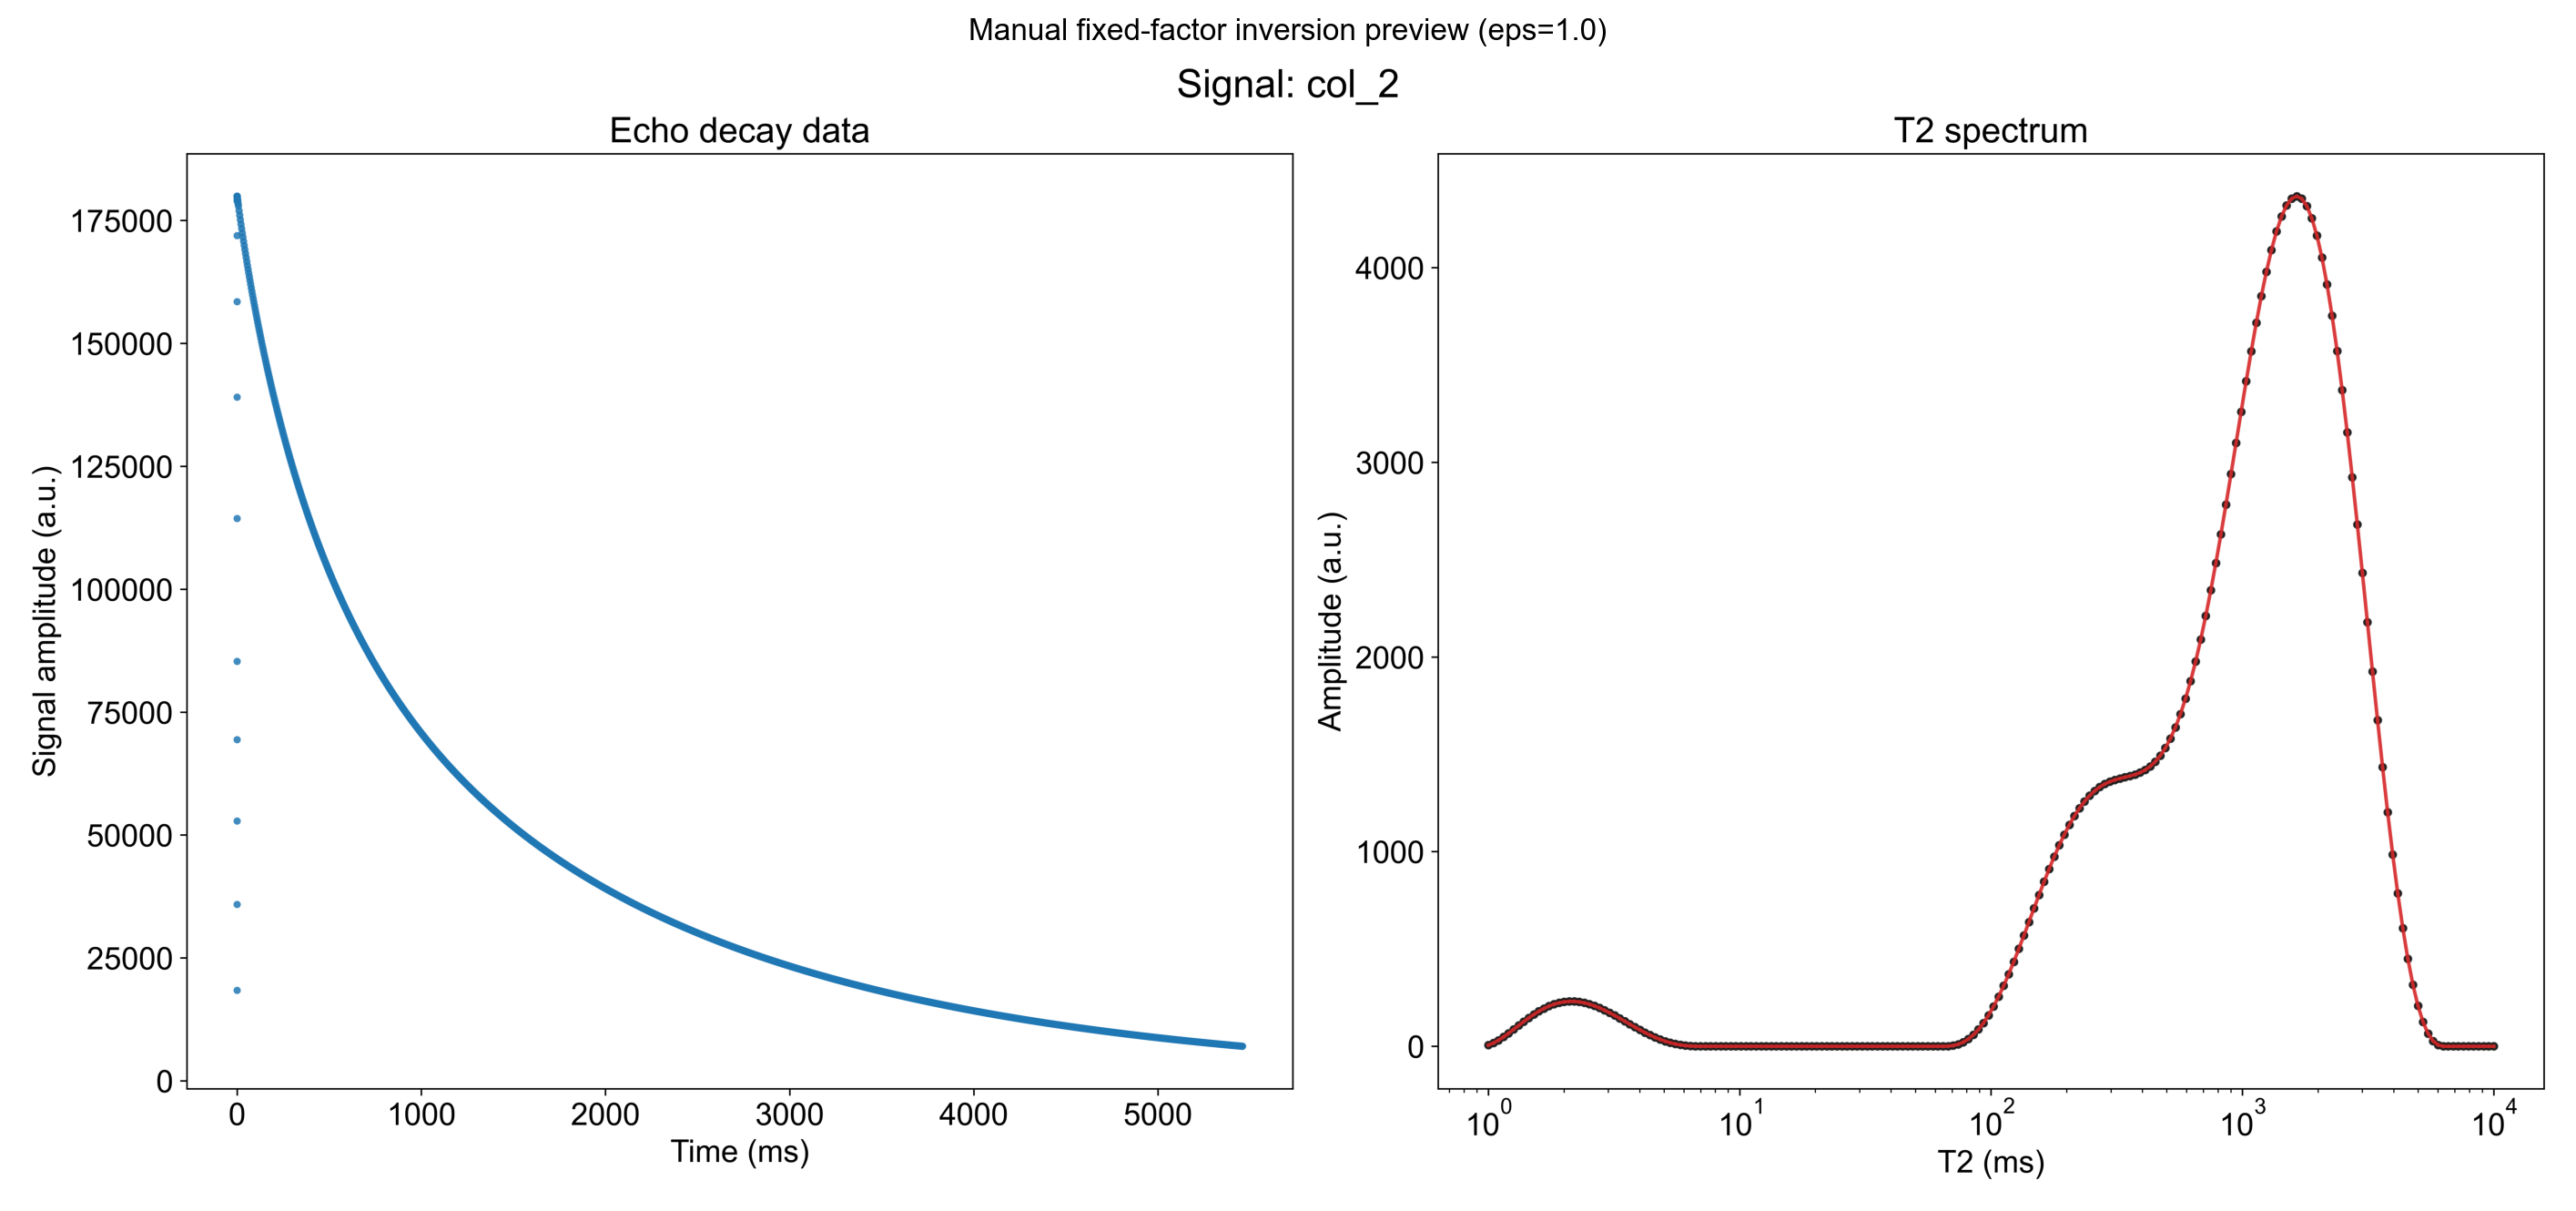

In [4]:
# Manual fixed smoothing-factor inversion and visualization.
# Change this value manually for sensitivity checks (e.g., 0.3, 1.0, 3.0).
manual_fixed_smoothing_factor = 1.0

manual_fixed_output_dir = output_root / f"nnls_manual_eps_{manual_fixed_smoothing_factor:g}".replace(".", "p")

manual_nnls_outputs = run_nnls_workbook(
    input_workbook=simulation_decay_file,
    output_dir=manual_fixed_output_dir,
    config=NnlsConfig(
        num_bins=200,
        regularization=manual_fixed_smoothing_factor,
        t2_min_ms=1.0,
        t2_max_ms=1e4,
        min_points_after_trim=10,
    ),
    time_to_ms_scale=1000.0,
    trim_from_peak=True,
)

manual_plot_outputs = run_plotting_workbook_pair(
    raw_decay_workbook=simulation_decay_file,
    spectrum_workbook=manual_nnls_outputs["spectrum_xlsx"],
    output_dir=manual_fixed_output_dir / "plots",
    plot_config=PlotConfig(
        figure_size_pair=(18, 8),
        dpi=600,
        font_family_candidates=("Helvetica", "Arial", "DejaVu Sans"),
        minimum_font_size=16,
        axis_title_font_size=18,
        axis_label_font_size=16,
        figure_title_font_size=20,
        tick_label_font_size=16,
        legend_font_size=16,
        annotation_font_size=16,
    ),
    time_to_ms_scale=1000.0,
)

print(f"Manual fixed smoothing factor: {manual_fixed_smoothing_factor}")
print("Manual inversion outputs:")
for key, value in manual_nnls_outputs.items():
    print(f"  - {key}: {value}")

manual_sheet_map = pd.read_excel(manual_nnls_outputs["spectrum_xlsx"], sheet_name=None)
manual_first_signal = next(iter(manual_sheet_map))
manual_head5 = manual_sheet_map[manual_first_signal].head(5)
print(f"\nManual fixed-factor inversion table (head 5) for signal: {manual_first_signal}")
display(manual_head5)

manual_figure_path = next(iter(manual_plot_outputs.values()))
print(f"\nPreview manual fixed-factor inversion figure (high-res): {manual_figure_path}")

manual_img = plt.imread(str(manual_figure_path))
plt.figure(figsize=(18, 10), dpi=200)
plt.imshow(manual_img)
plt.title(f"Manual fixed-factor inversion preview (eps={manual_fixed_smoothing_factor})")
plt.axis("off")
plt.show()

## 2) L-curve inversion

In [5]:
# Run L-curve inversion on simulation data with high-resolution figure export.
# The algorithm scans alpha values in log-space and selects the best alpha
# by reciprocal-slope criterion.
lcurve_plot_config = PlotConfig(
    figure_size_single=(12, 9),
    dpi=600,
    font_family_candidates=("Helvetica", "Arial", "DejaVu Sans"),
    minimum_font_size=16,
    axis_title_font_size=18,
    axis_label_font_size=16,
    figure_title_font_size=20,
    tick_label_font_size=16,
    legend_font_size=16,
    annotation_font_size=16,
 )

lcurve_outputs = run_lcurve_workbook(
    input_workbook=simulation_decay_file,
    output_dir=output_root / "lcurve_simulation",
    config=LCurveConfig(
        num_bins=200,
        t2_min_ms=1e-2,
        t2_max_ms=1e5,
        alpha_min=1e-6,
        alpha_max=1e2,
        alpha_count=60,
        slope_reciprocal_target=0.25,
        slope_reciprocal_valid_range=(0.1, 10.0),
        min_points_after_trim=10,
    ),
    plot_config=lcurve_plot_config,
    time_to_ms_scale=1000.0,
    trim_from_peak=True,
)

print("L-curve outputs:")
for key, value in lcurve_outputs.items():
    print(f"  - {key}: {value}")

# Preview the first 5 rows of L-curve inversion spectrum table.
lcurve_spectrum_sheet_map = pd.read_excel(lcurve_outputs["spectrum_xlsx"], sheet_name=None)
lcurve_first_signal_name = next(iter(lcurve_spectrum_sheet_map))
lcurve_inversion_head5 = lcurve_spectrum_sheet_map[lcurve_first_signal_name].head(5)

print(f"\nL-curve inversion table (head 5) for signal: {lcurve_first_signal_name}")
display(lcurve_inversion_head5)

# Compare fixed smoothing factor (eps=1) against L-curve selected regularization.
fixed_summary_df = pd.read_csv(nnls_sim_outputs["summary_csv"])
lcurve_summary_df = pd.read_csv(lcurve_outputs["summary_csv"])

comparison_df = fixed_summary_df.merge(
    lcurve_summary_df[
        [
            "signal_name",
            "best_regularization",
            "best_residual_norm",
            "best_roughness_norm",
            "best_slope_reciprocal",
        ]
    ],
    on="signal_name",
    how="inner",
)
comparison_df["fixed_regularization"] = fixed_smoothing_factor
comparison_df["delta_residual_norm_fixed_minus_lcurve"] = (
    comparison_df["residual_norm"] - comparison_df["best_residual_norm"]
)
comparison_df["delta_roughness_norm_fixed_minus_lcurve"] = (
    comparison_df["roughness_norm"] - comparison_df["best_roughness_norm"]
)

print("\nComparison: fixed smoothing factor vs L-curve best parameter (head 5)")
display(comparison_df.head(5))

L-curve outputs:
  - spectrum_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\lcurve_simulation\SimulationDecay__lcurve_spectrum.xlsx
  - metrics_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\lcurve_simulation\SimulationDecay__lcurve_metrics.xlsx
  - trimmed_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\lcurve_simulation\SimulationDecay__lcurve_trimmed_decay.xlsx
  - summary_csv: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\lcurve_simulation\SimulationDecay__lcurve_summary.csv
  - summary_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\lcurve_simulation\SimulationDecay__lcurve_summary.xlsx
  - figure_dir: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\lcurve_simulation\SimulationDecay__lcurve_figures

L-curve inversion table

,t2_ms,amplitude
0,0.010000,185.671742
1,0.010844,121.144292
2,0.011758,0.000000
3,0.012751,0.000000
4,0.013826,0.000000



Comparison: fixed smoothing factor vs L-curve best parameter (head 5)


,signal_name,regularization,residual_norm,roughness_norm,raw_points,trimmed_points,peak_index_in_sorted_raw,best_regularization,best_residual_norm,best_roughness_norm,best_slope_reciprocal,fixed_regularization,delta_residual_norm_fixed_minus_lcurve,delta_roughness_norm_fixed_minus_lcurve
0,col_2,1.0,133.301672,123.608685,1604,1586,18,0.000148,4.814499,15522.010007,0.22687,1.0,128.487173,-15398.401322


## 3) Plotting

Generated 1 high-resolution inversion plot(s):
  - col_2: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\plots\SimulationDecay__col_2__decay_t2.png

Preview L-curve figure (high-res): c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\lcurve_simulation\SimulationDecay__lcurve_figures\col_2__lcurve.png
Preview fixed-factor inversion figure (high-res): c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\plots\SimulationDecay__col_2__decay_t2.png


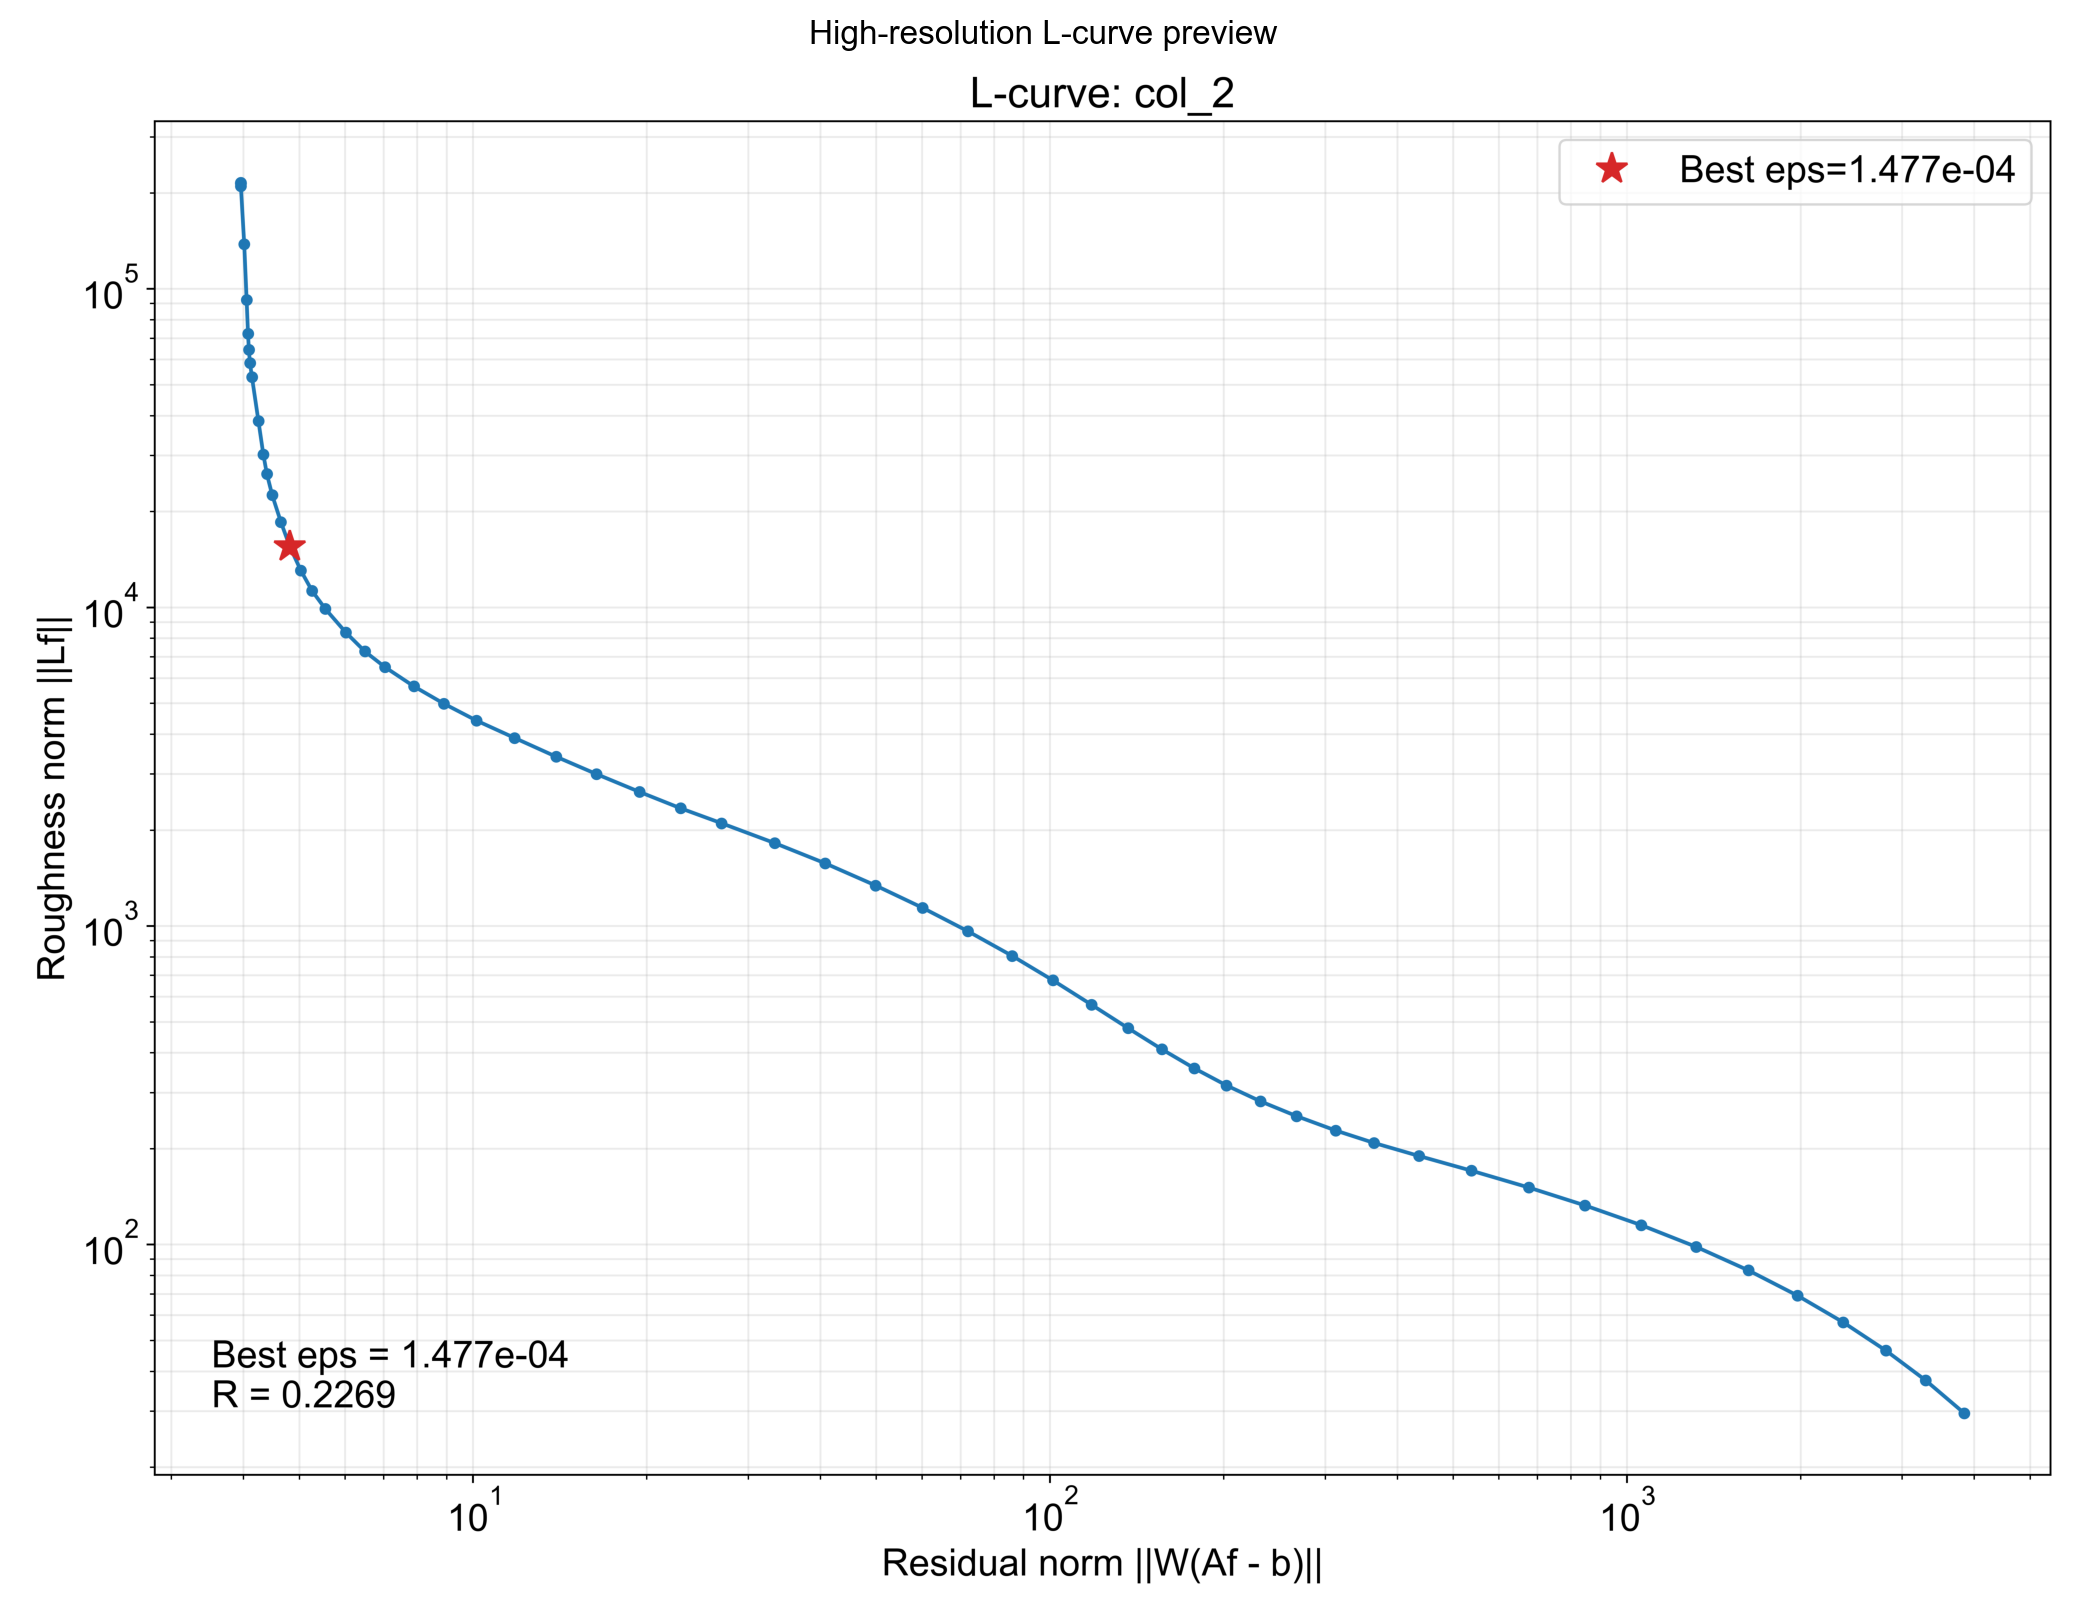

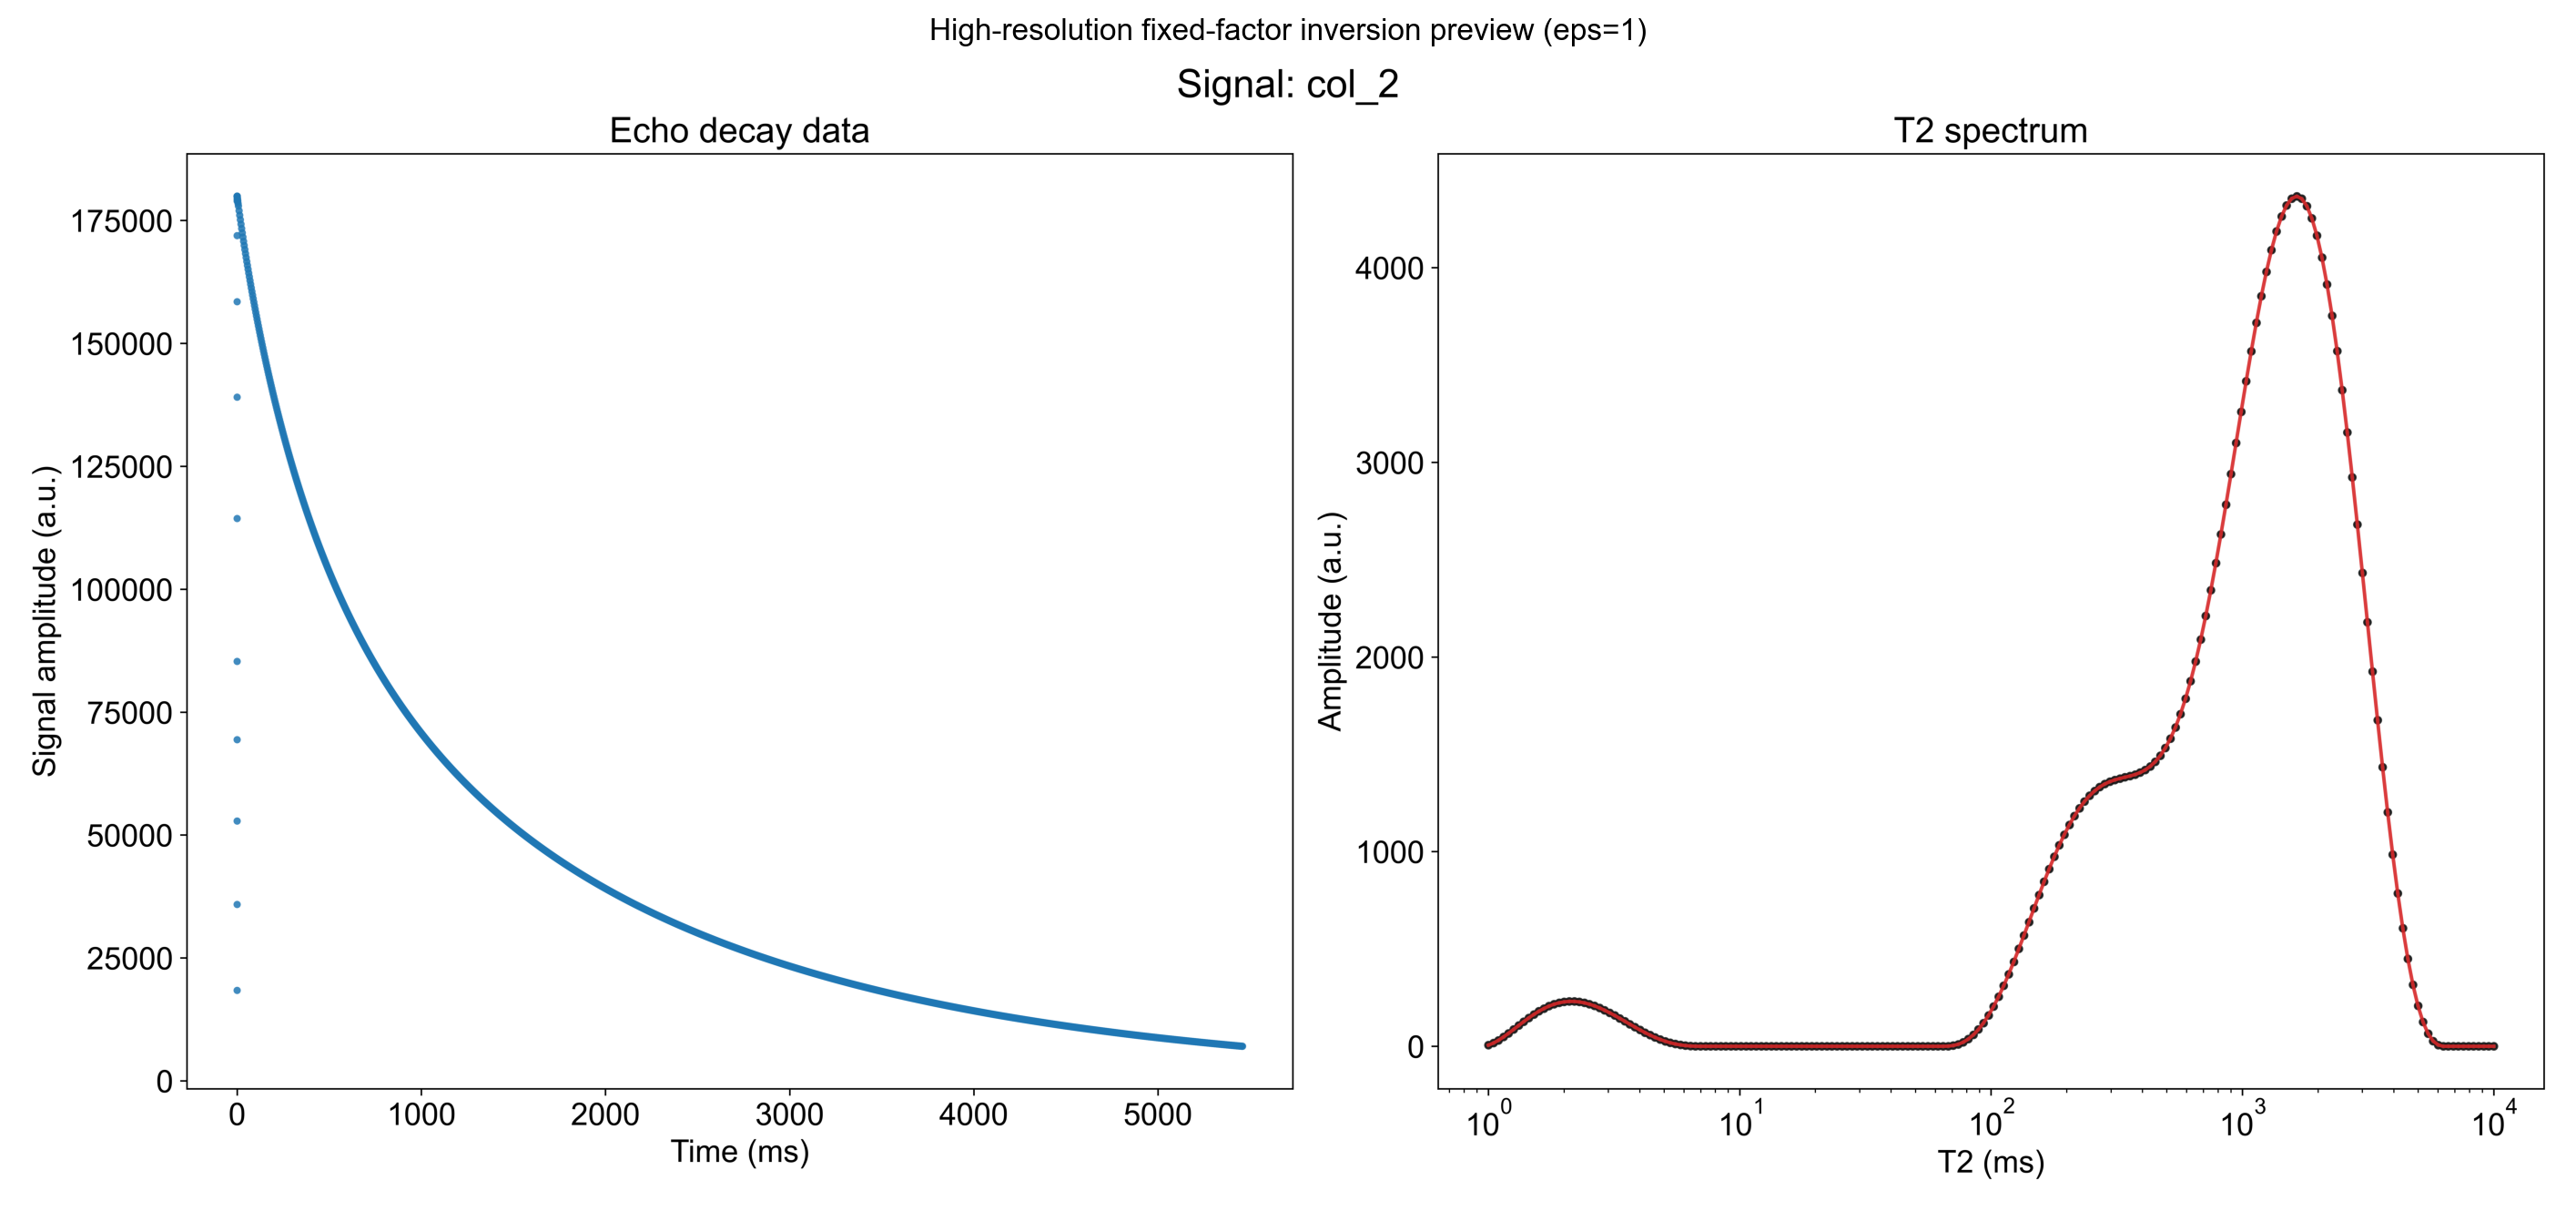

In [6]:
# Plot fixed-factor (eps=1) inversion results with high-resolution export.
high_res_plot_config = PlotConfig(
    figure_size_pair=(18, 8),
    dpi=600,
    font_family_candidates=("Helvetica", "Arial", "DejaVu Sans"),
    minimum_font_size=16,
    axis_title_font_size=18,
    axis_label_font_size=16,
    figure_title_font_size=20,
    tick_label_font_size=16,
    legend_font_size=16,
    annotation_font_size=16,
)

plot_outputs = run_plotting_workbook_pair(
    raw_decay_workbook=simulation_decay_file,
    spectrum_workbook=nnls_sim_outputs["spectrum_xlsx"],
    output_dir=output_root / "plots",
    plot_config=high_res_plot_config,
    time_to_ms_scale=1000.0,
)

print(f"Generated {len(plot_outputs)} high-resolution inversion plot(s):")
for signal_name, figure_path in plot_outputs.items():
    print(f"  - {signal_name}: {figure_path}")

# Preview one L-curve figure and one fixed-factor inversion figure at larger display size.
inversion_figure_path = next(iter(plot_outputs.values()))
lcurve_figure_candidates = sorted(lcurve_outputs["figure_dir"].glob("*.png"))
if not lcurve_figure_candidates:
    raise FileNotFoundError("No L-curve figure found in the output directory.")
lcurve_figure_path = lcurve_figure_candidates[0]

print(f"\nPreview L-curve figure (high-res): {lcurve_figure_path}")
print(f"Preview fixed-factor inversion figure (high-res): {inversion_figure_path}")

lcurve_img = plt.imread(str(lcurve_figure_path))
inversion_img = plt.imread(str(inversion_figure_path))

plt.figure(figsize=(16, 10), dpi=200)
plt.imshow(lcurve_img)
plt.title("High-resolution L-curve preview")
plt.axis("off")
plt.show()

plt.figure(figsize=(18, 10), dpi=200)
plt.imshow(inversion_img)
plt.title("High-resolution fixed-factor inversion preview (eps=1)")
plt.axis("off")
plt.show()

## 4) Gaussian peak decomposition

Gaussian decomposition outputs:
  - peak_table_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\gaussian\SimulationDecay__nnls_spectrum__gaussian_peak_table.xlsx
  - fit_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\gaussian\SimulationDecay__nnls_spectrum__gaussian_fit.xlsx
  - summary_csv: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\gaussian\SimulationDecay__nnls_spectrum__gaussian_summary.csv
  - summary_xlsx: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\gaussian\SimulationDecay__nnls_spectrum__gaussian_summary.xlsx
  - figure_dir: c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\gaussian\SimulationDecay__nnls_spectrum__gaussian_figures

Preview Gaussian decomposition figure (high-res): c:\Users\imgw\python\research\bnmr_mcmc-main\T2反演方法验证\T2_process\outputs_standard_demo\g

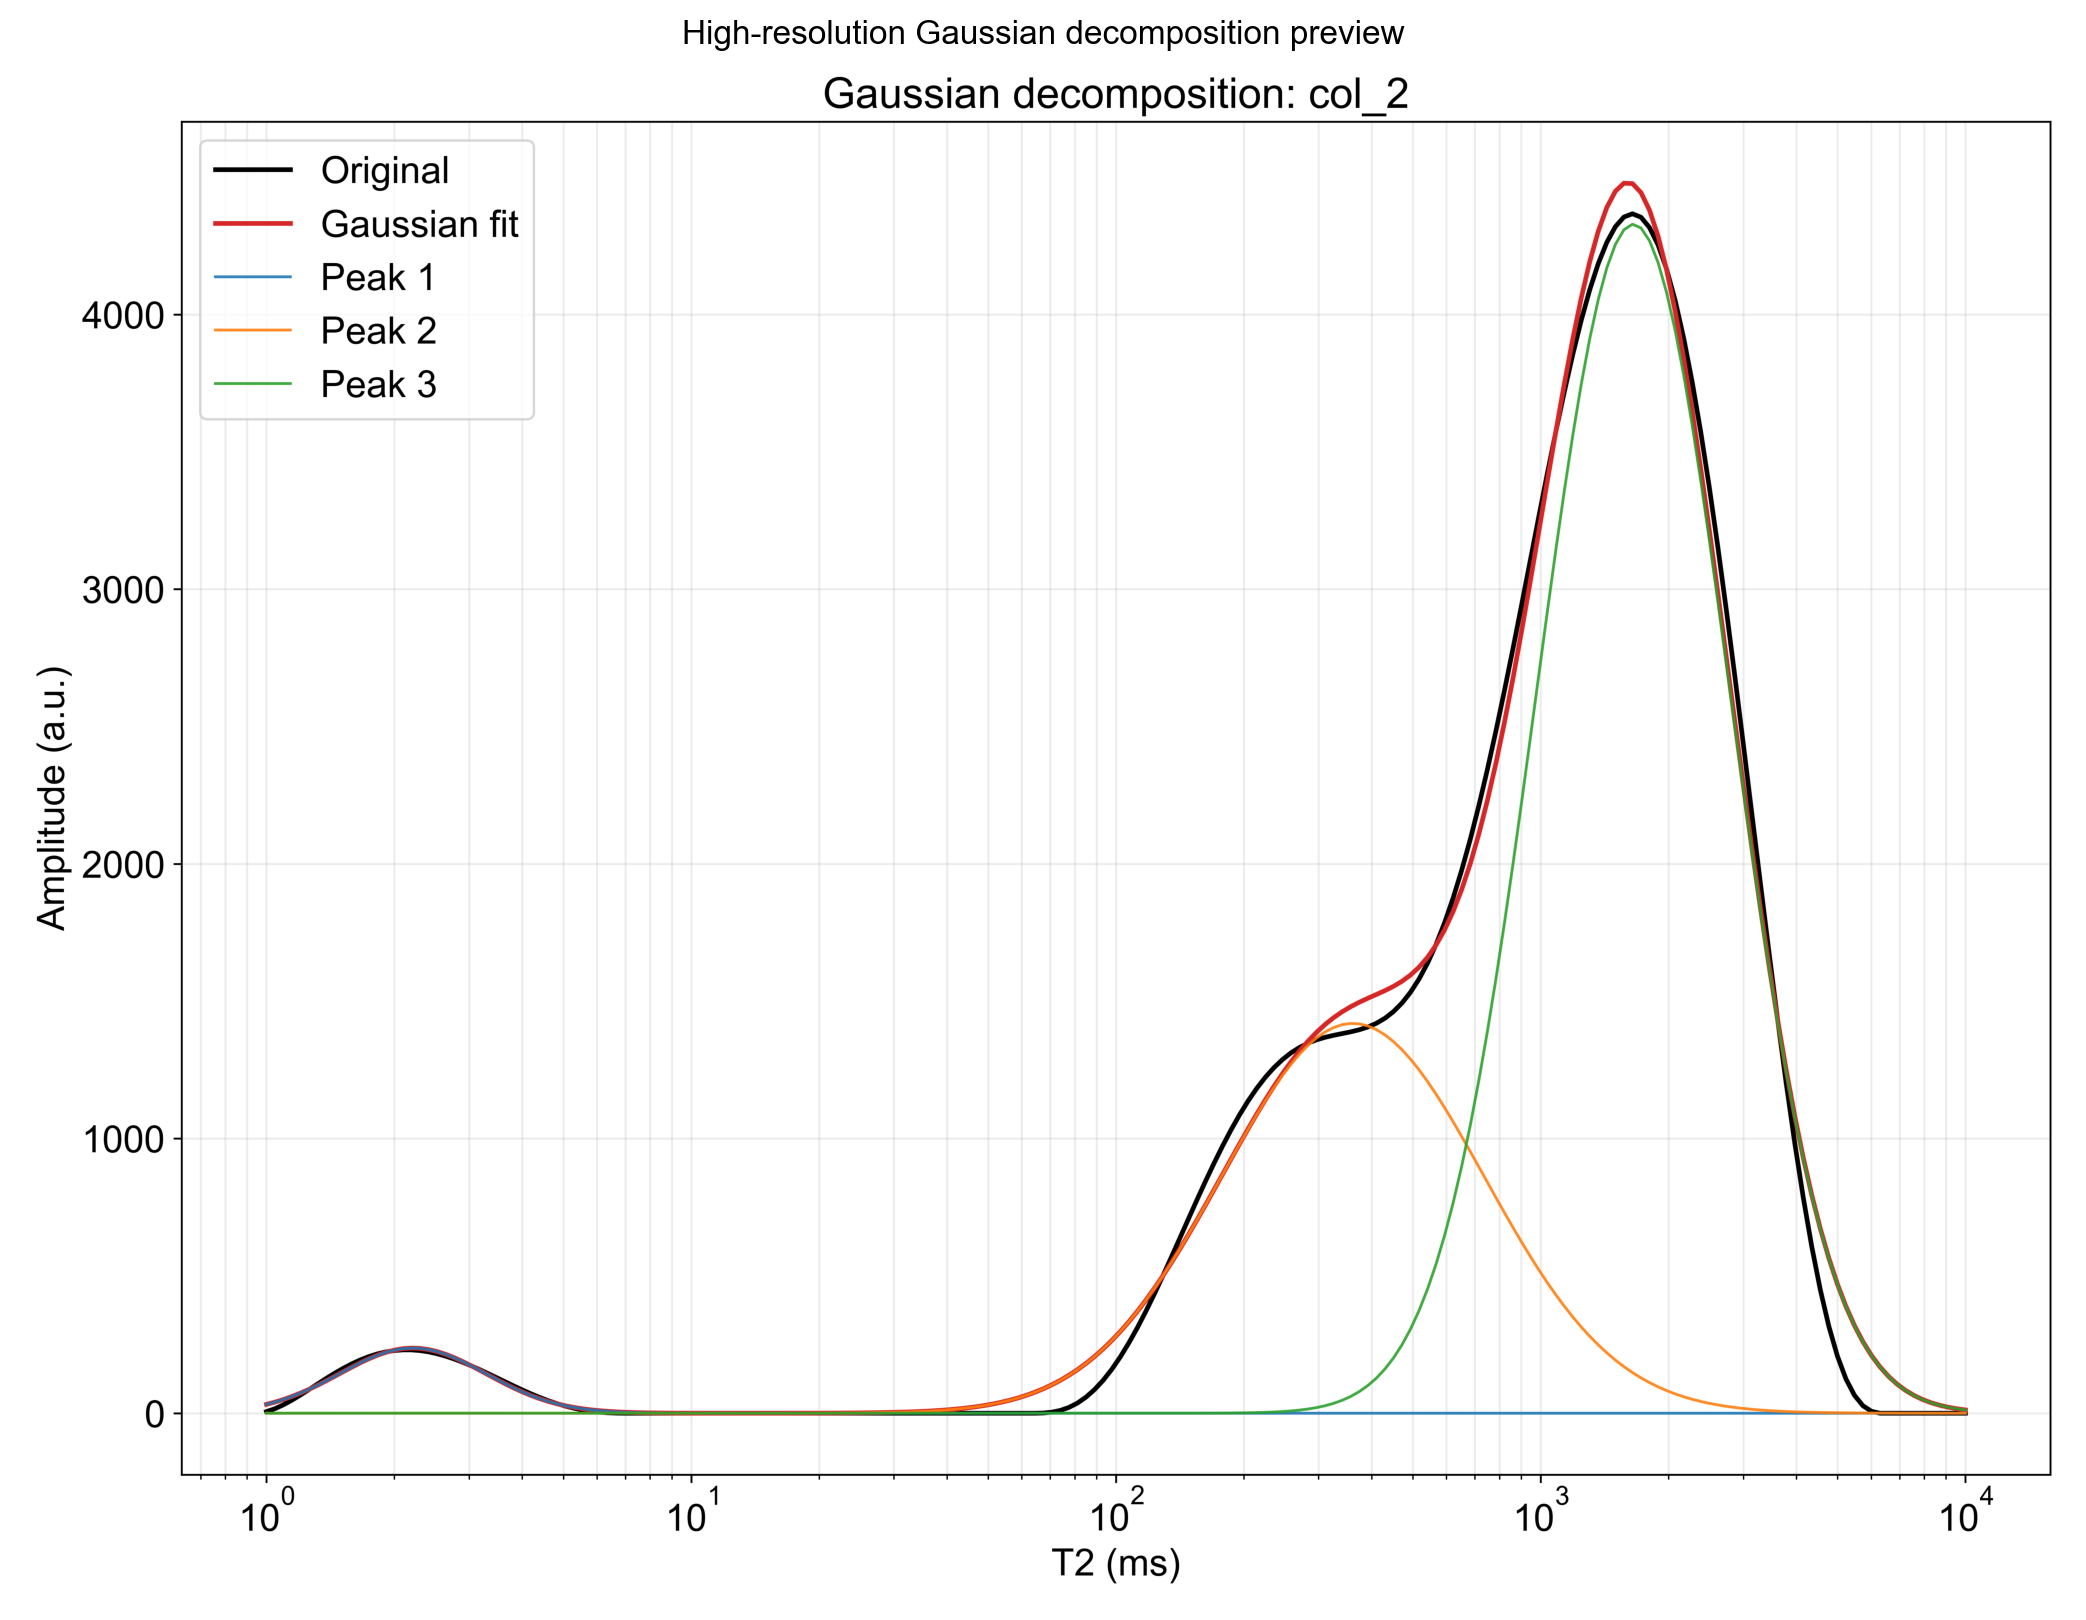

In [7]:
# Perform Gaussian decomposition directly on the fixed-factor NNLS spectrum workbook
# and export high-resolution Gaussian decomposition figures.
gaussian_plot_config = PlotConfig(
    figure_size_single=(12, 9),
    dpi=600,
    font_family_candidates=("Helvetica", "Arial", "DejaVu Sans"),
    minimum_font_size=16,
    axis_title_font_size=18,
    axis_label_font_size=16,
    figure_title_font_size=20,
    tick_label_font_size=16,
    legend_font_size=16,
    annotation_font_size=16,
)

gaussian_outputs = run_gaussian_decomposition_on_spectrum_workbook(
    spectrum_workbook=nnls_sim_outputs["spectrum_xlsx"],
    output_dir=output_root / "gaussian",
    config=GaussianConfig(peak_count=3),
    plot_config=gaussian_plot_config,
)

print("Gaussian decomposition outputs:")
for key, value in gaussian_outputs.items():
    print(f"  - {key}: {value}")

# Preview one high-resolution Gaussian decomposition figure.
gaussian_figure_candidates = sorted(gaussian_outputs["figure_dir"].glob("*.png"))
if not gaussian_figure_candidates:
    raise FileNotFoundError("No Gaussian decomposition figure found in the output directory.")

gaussian_figure_path = gaussian_figure_candidates[0]
print(f"\nPreview Gaussian decomposition figure (high-res): {gaussian_figure_path}")

gaussian_img = plt.imread(str(gaussian_figure_path))
plt.figure(figsize=(16, 10), dpi=200)
plt.imshow(gaussian_img)
plt.title("High-resolution Gaussian decomposition preview")
plt.axis("off")
plt.show()

## 5) Optional: quick output tree preview

In [15]:
# Print generated files for quick verification.
for path in sorted(output_root.rglob("*")):
    if path.is_file():
        print(path.relative_to(output_root))

gaussian\SimulationDecay__nnls_spectrum__gaussian_figures\col_2__gaussian.png
gaussian\SimulationDecay__nnls_spectrum__gaussian_fit.xlsx
gaussian\SimulationDecay__nnls_spectrum__gaussian_peak_table.xlsx
gaussian\SimulationDecay__nnls_spectrum__gaussian_summary.csv
gaussian\SimulationDecay__nnls_spectrum__gaussian_summary.xlsx
lcurve\SimulationDecay__lcurve_figures\col_2__lcurve.png
lcurve\SimulationDecay__lcurve_metrics.xlsx
lcurve\SimulationDecay__lcurve_spectrum.xlsx
lcurve\SimulationDecay__lcurve_summary.csv
lcurve\SimulationDecay__lcurve_summary.xlsx
lcurve\SimulationDecay__lcurve_trimmed_decay.xlsx
lcurve_simulation\SimulationDecay__lcurve_figures\col_2__lcurve.png
lcurve_simulation\SimulationDecay__lcurve_metrics.xlsx
lcurve_simulation\SimulationDecay__lcurve_spectrum.xlsx
lcurve_simulation\SimulationDecay__lcurve_summary.csv
lcurve_simulation\SimulationDecay__lcurve_summary.xlsx
lcurve_simulation\SimulationDecay__lcurve_trimmed_decay.xlsx
nnls\SimulationDecay__nnls_fit.xlsx
nnls